```text
Drift
├── Import & Setup
└── Calculate feature drift
   
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.drift import calculate_drift
from src.preprocessing import input_load
from src.plots import plot_drift

# Dataset specific settings

from src import settings

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = input_load(2016, 2021)

## Calculate feature drift

- **Scope**
  - Assess distributional stability of selected important PD model inputs over time (input drift).
  - Reference period: **2016–2018** (development period).
  - Comparison periods: **2019, 2020** (calibration period) and **2021** (out-of-time period).
  - Use the **KS statistic and p-value** for numerical variables and **PSI** as the drift measure.

- **Key Findings**
  - Drift is not uniform across variables.
  - **NewCreditCustomer** remains relatively stable throughout the post-development periods.
  - **Age** shows a gradual increase in distributional drift from 2019 through 2021.
  - **CreditScoreEeMini** remains relatively stable during 2019 and 2020 but shows a larger shift in 2021.
  - **HomeOwnershipType** shows substantial categorical drift, increasing over the post-development periods.
  - **LiabilitiesTotal** shows substantial but non-monotonic distributional changes, with the largest PSI in 2020.
  - **PreviousRepaymentsBeforeLoan** shows a large and persistent shift relative to the development population.
  - **Amount** shows particularly large distributional changes; these may reflect changes in the portfolio or lending strategy.

In [4]:
# variables to monitor

DRIFT_NUMERIC_FEATURES = [
    "CreditScoreEeMini",
    "Age",
    "PreviousRepaymentsBeforeLoan",
    "Amount",
    "LiabilitiesTotal"
]

DRIFT_CATEGORICAL_FEATURES = [
    "NewCreditCustomer",
    "HomeOwnershipType",
]

,Variable,Type,Reference,Comparison,KS,p_value,KS_significant,PSI
1,Age,numeric,2016-2018,2016-2018,0.000000,1.000000e+00,False,0.000000
8,Age,numeric,2016-2018,2019-2019,0.031946,3.427804e-14,True,0.009065
15,Age,numeric,2016-2018,2020-2020,0.058549,6.007144e-38,True,0.027080
22,Age,numeric,2016-2018,2021-2021,0.088700,3.448868e-110,True,0.046196
3,Amount,numeric,2016-2018,2016-2018,0.000000,1.000000e+00,False,0.000000
10,Amount,numeric,2016-2018,2019-2019,0.113030,3.965016e-173,True,0.223096
17,Amount,numeric,2016-2018,2020-2020,0.265281,0.000000e+00,True,1.880106
24,Amount,numeric,2016-2018,2021-2021,0.250402,0.000000e+00,True,4.031434
0,CreditScoreEeMini,numeric,2016-2018,2016-2018,0.000000,1.000000e+00,False,0.000000
7,CreditScoreEeMini,numeric,2016-2018,2019-2019,0.014722,2.374114e-03,True,0.001863


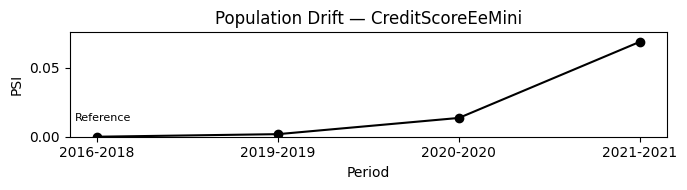

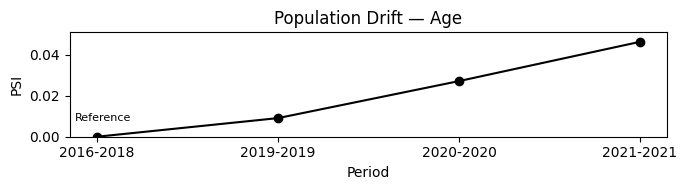

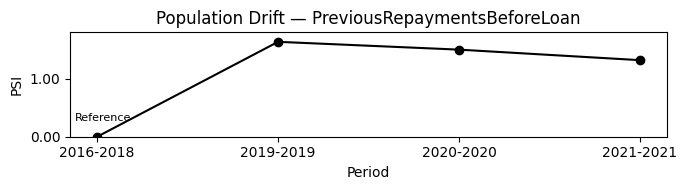

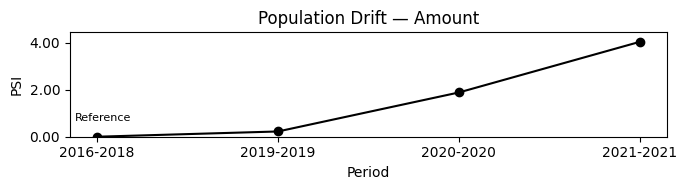

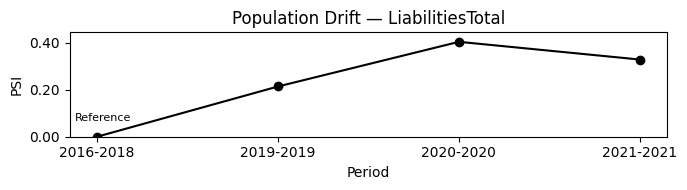

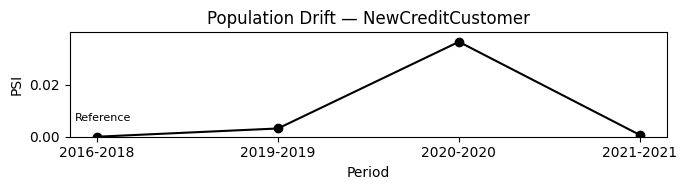

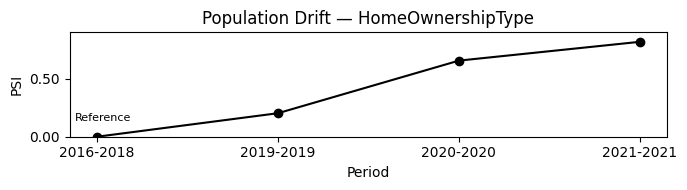

In [5]:
# calculate, display, plot

drift_results = calculate_drift(df=portfolio,
                numeric_variables=DRIFT_NUMERIC_FEATURES,
                categorical_variables=DRIFT_CATEGORICAL_FEATURES,
                time_column="LoanDate",
                reference_period=(2016, 2018),
                comparison_periods=[
                (2016, 2018),
                (2019, 2019),
                (2020, 2020),
                (2021, 2021),])

display(drift_results.sort_values(['Variable', 'Comparison']))

for variable in DRIFT_NUMERIC_FEATURES:
    plot = plot_drift(drift_results, variable)
for variable in DRIFT_CATEGORICAL_FEATURES:
    plot = plot_drift(drift_results, variable)